/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x uni

1.035838635853445
1.035838635853445
1.0358386358534448
1.035838635853445
1.0358386358534444
1.035838635853445
1.0358386358534448
1.0358386358534453
1.0358386358534442
1.0358386358534448
1.0358386358534442
1.035838635853445
1.0358386358534446
1.0358386358534446


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x uni

1.0358386358534444
1.0358386358534446
1.0358386358534446
1.0358386358534448
1.035838635853445
1.035838635853445
1.0358386358534446
1.0358386358534444
1.0358386358534444
1.035838635853445
1.0358386358534446


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(
/scratch/local/25518794/ipykernel_3000305/3803694212.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


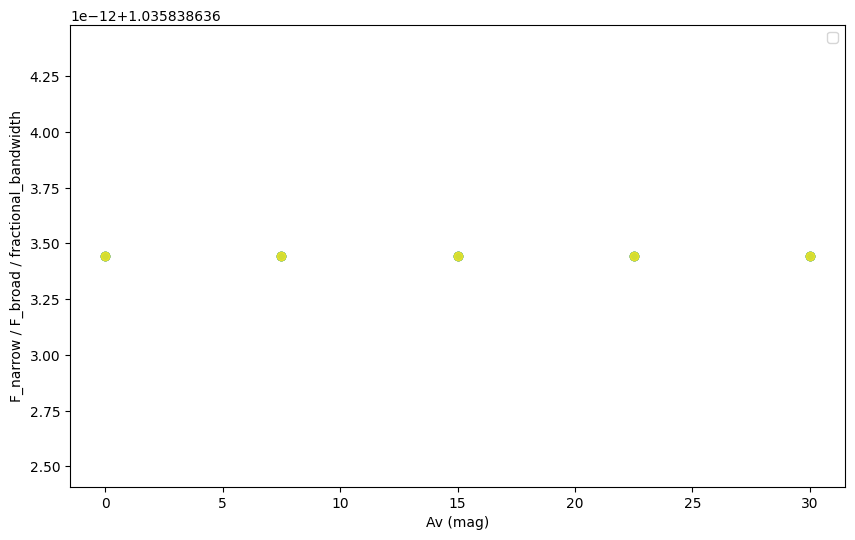

In [13]:
# make blackbody models with different tempearture and also models attenuated by dust extinction with various Av values
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy import constants as const
from astropy.modeling import models
from astropy.modeling import fitting
from dust_extinction.averages import RL85_MWGC, G21_MWAvg
from dust_extinction.parameter_averages import CCM89
from astroquery.svo_fps import SvoFps
def get_ratio(wavelength, sed, narrow, wide):

   

    wavelength_table_narrow = SvoFps.get_transmission_data(f'JWST/NIRCAM.{narrow}')
    wavelength_table_wide = SvoFps.get_transmission_data(f'JWST/NIRCAM.{wide}')

    waves_wide = wavelength_table_wide['Wavelength']
    trans_narrow = np.interp(waves_wide, wavelength_table_narrow['Wavelength'], wavelength_table_narrow['Transmission'])
    trans_wide = wavelength_table_wide['Transmission']


    # interpolate SED and wavelength to make the same cadence with waves_wide
    data_interpolated = np.interp(waves_wide, wavelength, sed)


    integrated_wide = (trans_wide/trans_wide.max() * data_interpolated).sum()
    integrated_narrow = (trans_narrow/trans_narrow.max() * data_interpolated).sum()
    

    fractional_bandwidth = ( (trans_wide/trans_wide.max()) * (trans_narrow/trans_narrow.max()) ).sum() / (trans_wide/trans_wide.max()).sum()
    
    return integrated_narrow / integrated_wide / fractional_bandwidth
ext = G21_MWAvg()
temperatures = np.linspace(3000, 10000, 5) * u.K
microns = np.linspace(1, 10, 1000) * u.micron

cmap = plt.get_cmap('viridis')
Avs = np.linspace(0, 30, 5)
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
for temp in temperatures:
    for Av in Avs:
        bb = models.BlackBody(temperature=temp)
       
        flux = bb(microns)
        flux_ext = flux * 10**(-0.4*ext(microns)*Av)
        bra_ratio = get_ratio(microns.value, flux_ext.value, 'f187n', 'f182m')
        ax.scatter(Av, bra_ratio, color=cmap(temp.value/10000), alpha=0.7)
        print(bra_ratio)
plt.xlabel('Av (mag)')
plt.ylabel('F_narrow / F_broad / fractional_bandwidth')
#plt.xscale('log')
plt.legend()
plt.show()





